# DataDriven_Soccer_Scouting

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models
import time

import warnings
warnings.filterwarnings("ignore")



start_time = time.time()

## Introduction and EDA

In [3]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

# Keep "Position" column instead of "pos"
df.drop(columns=['pos'], inplace=True)
df = df.rename(columns={'Position': 'pos'})

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,age,born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot,pos
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,26,1997,17,13,1198,...,28,214,55,813,367,813,NaN,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,22,2001,25,20,1729,...,162,57,6,978,216,979,178.0,65.0,Left,RW
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,28,1995,38,38,3420,...,0,1388,880,1480,92,1480,183.0,75.0,Right,GK
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,25,1999,35,33,2825,...,81,325,82,1948,909,1948,185.0,80.0,Right,CDM
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,26,1997,28,28,2363,...,40,672,189,1873,985,1873,NaN,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [4]:
# Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3392 
- columns: 117


In [5]:
# Select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,Preferred foot,pos
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,Left,RW
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,Right,CDM
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,Right,LW
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,Left,CB
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,Right,RB


In [6]:
# Rename 'Preferred foot' to 'preferred_foot' for consistency
df.rename(columns={'Preferred foot': 'preferred_foot'}, inplace=True)

# Convert preferred_foot to binary (1 for 'Right', 0 for 'Left')
df['preferred_foot_binary'] = df['preferred_foot'].map({'Right': 1, 'Left': 0})

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age', 'preferred_foot']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Matrix 'X' shape: 3392 players x 109 statistics


## Similarity Search

### PCA

In [ ]:
# ----------------------------------------------
# NON RIMUOVERE QUESTA CELLA
# ----------------------------------------------
df_info_reset = df_info.reset_index(drop=True)

### Deep Autoencoder

#### Mix ReLU

In [8]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_relu = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_mix_relu = pd.concat([df_info_reset, df_ae_mix_relu], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1]\n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU + tanh mix)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of features, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Model

#### Mix Tanh

In [9]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_mix_tanh = pd.concat([df_info_reset, df_ae_mix_tanh], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1]\n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU + tanh mix)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of features, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Model

#### Relu

In [10]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu = pd.concat([df_info_reset, df_ae_relu], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Mode

#### Tanh

--- Building Deep Autoencoder (TensorFlow/Keras) ---



Training in progress...
Epoch 1/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2319
Epoch 2/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1464
Epoch 3/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1261
Epoch 4/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1126
Epoch 5/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1048
Epoch 6/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0998
Epoch 7/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0964
Epoch 8/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0939
Epoch 9/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0922
Epoch 10/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0912
Epoch 11/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0898
Epoch 12/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0886
Epoch 13/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0881
Epoch 14/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0875
Epoch 15/200
106/1

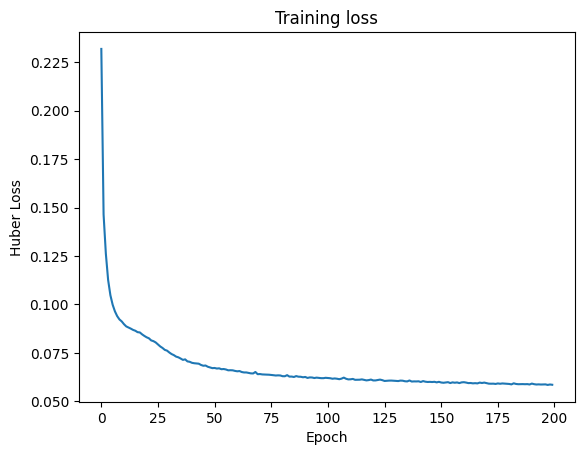


Extracting 10D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [11]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=200, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_tanh.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae_tanh], axis=1)

#### ReLU with dropout

In [12]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=500, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_dropout = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(128, activation=\'relu\')(input_layer)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(64, activation=\'relu\')(encoded)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\ndecoded = layers.Dropout(0.2)(decoded)\ndecoded = layers.Dense(128, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = la

#### Tanh with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2158
Epoch 2/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1545
Epoch 3/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1390
Epoch 4/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1312
Epoch 5/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1274
Epoch 6/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1231
Epoch 7/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1206
Epoch 8/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1193
Epoch 9/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1161
Epoch 10/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1146
Epoch 11/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1128
Epoch 12/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1111
Epoch 13/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1092
Epoch 14/400
106/106 ━━━━━━━━━━━━━

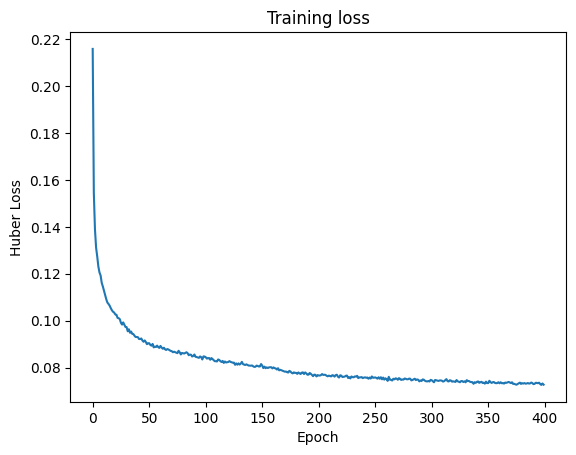


Extracting 10D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [13]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=400, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_tanh_dropout.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)

#### ReLU + Tanh bottleneck with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2914
Epoch 2/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1930
Epoch 3/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1755
Epoch 4/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1654
Epoch 5/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1595
Epoch 6/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1547
Epoch 7/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1496
Epoch 8/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1474
Epoch 9/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1430
Epoch 10/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1422
Epoch 11/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1394
Epoch 12/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1369
Epoch 13/400
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1364
Epoch 14/400
106/106 ━━━━━━━━━━━━━

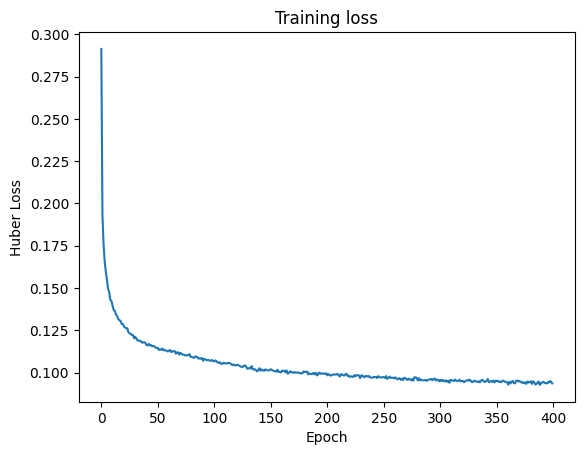


Extracting 10D DNA representation...
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [14]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space, bounded by tanh)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=400, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_relu_tanh_btn.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_tanh_btn = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu_tanh_btn = pd.concat([df_info_reset, df_ae_relu_tanh_btn], axis=1)

#### Testing Autoencoder

##### Similarity Functions

In [15]:
def find_similar_ae(player_name, player_season, latent_df, top_n=5, max_age=None, season_filter=None, same_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (latent_df['player'].str.lower() == player_name.lower())
        & (latent_df['season'] == player_season)
    )
    player_idx = latent_df[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df.loc[idx, 'player']
    real_team = latent_df.loc[idx, 'team']
    season = latent_df.loc[idx, 'season']
    role = latent_df.loc[idx, 'pos']

    print(f"\n[AUTOENCODER] Searching similar players for: {real_player} ({real_team} - {season})")

    # Extract target player's 10 latent values
    player_vector = latent_df.loc[idx, ae_columns].values.reshape(1, -1)
    # Extract all players' latent values
    all_vectors = latent_df[ae_columns].values

    # Compute cosine similarity
    similarity = cosine_similarity(player_vector, all_vectors)[0]

    # Assign scores
    latent_df_temp = latent_df.copy()
    latent_df_temp['Similarity_Score'] = similarity

    # Exclude target player from results
    latent_df_temp = latent_df_temp.drop(index=idx)

    # Optional age filter
    if max_age is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['age'] <= max_age]

    # Optional season filter
    if season_filter is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['season'] == season_filter]

    # Optional position filter
    if same_position:
        latent_df_temp = latent_df_temp[latent_df_temp['pos'] == role]

    # Optional league filter
    if same_league:
        latent_df_temp = latent_df_temp[latent_df_temp['league'] == latent_df.loc[idx, 'league']]

    # Optional preferred-foot filter
    if same_preferred_foot:
        latent_df_temp = latent_df_temp[latent_df_temp['preferred_foot'] == latent_df.loc[idx, 'preferred_foot']]

    latent_df_temp = latent_df_temp[latent_df_temp['player'] != player_name]

    # Sort from most similar to least similar
    similar_players = latent_df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()

    # Format score as a readable percentage
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    output_columns = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return similar_players[output_columns]

In [16]:
def find_similar_ensemble(
    player_name,
    player_season,
    latent_df_a=df_latent_ae_relu_tanh_btn,
    latent_df_b=df_latent_ae_tanh_dropout,
    latent_df_c=df_latent_ae_tanh,
    top_n=5,
    max_age=None,
    season_filter=None,
    same_position=False,
    same_league=False
):
    # Target player
    mask_target = (
        (latent_df_a['player'].str.lower() == player_name.lower())
        & (latent_df_a['season'] == player_season)
    )
    player_idx = latent_df_a[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df_a.loc[idx, 'player']
    real_team = latent_df_a.loc[idx, 'team']
    season = latent_df_a.loc[idx, 'season']
    role = latent_df_a.loc[idx, 'pos']
    league = latent_df_a.loc[idx, 'league']

    print(f"\n[ENSEMBLE] Searching similar players for: {real_player} ({real_team} - {season})")

    # Average cosine similarity from the three latent spaces
    vector_a = latent_df_a.loc[idx, ae_columns].values.reshape(1, -1)
    vector_b = latent_df_b.loc[idx, ae_columns].values.reshape(1, -1)
    vector_c = latent_df_c.loc[idx, ae_columns].values.reshape(1, -1)
    sim_a = cosine_similarity(vector_a, latent_df_a[ae_columns].values)[0]
    sim_b = cosine_similarity(vector_b, latent_df_b[ae_columns].values)[0]
    sim_c = cosine_similarity(vector_c, latent_df_c[ae_columns].values)[0]
    sim_ensemble = (sim_a + sim_b + sim_c) / 3

    df_temp = latent_df_a.copy()
    df_temp['Similarity_Score'] = sim_ensemble
    df_temp = df_temp.drop(index=idx)

    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]

    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]

    if same_position:
        df_temp = df_temp[df_temp['pos'] == role]

    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    df_temp = df_temp[df_temp['player'] != player_name]

    similar_players = df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return similar_players[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

##### Testing

###### Single Testing

In [17]:
# Testing the models with a target player and season

target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    #'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    #'Mix ReLU': df_latent_ae_mix_relu,
    #'Mix Tanh': df_latent_ae_mix_tanh,
    #'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
    'ReLU + Tanh bottleneck': df_latent_ae_relu_tanh_btn,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    ae_results = find_similar_ae(
        player_name=target_player,
        player_season=target_season,
        latent_df=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=True
    )
    display(ae_results)

print("\n===== Model: Ensemble =====")
ensemble_results = find_similar_ensemble(
    player_name=target_player,
    player_season=target_season,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_position=True,
    same_league=False
)
display(ensemble_results)


===== Model: Tanh =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
2685,Ezequiel Ávila,28,Osasuna,RM,ESP-La Liga,2022 - 2023,87.9%
3042,Dodi Lukebakio,24,Hertha BSC,RM,GER-Bundesliga,2022 - 2023,77.6%
2176,Cyril Ngonge,23,Hellas Verona,RM,ITA-Serie A,2023 - 2024,76.4%
2209,Federico Chiesa,25,Juventus,RM,ITA-Serie A,2023 - 2024,74.0%
368,Dani Raba,28,Leganés,RM,ESP-La Liga,2024 - 2025,73.0%



===== Model: Tanh + Dropout =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
2176,Cyril Ngonge,23,Hellas Verona,RM,ITA-Serie A,2023 - 2024,94.2%
1296,Michael Olise,21,Crystal Palace,RM,ENG-Premier League,2023 - 2024,90.0%
1895,Donyell Malen,24,Dortmund,RM,GER-Bundesliga,2023 - 2024,89.8%
3017,Jesper Lindstrøm,22,Eint Frankfurt,RM,GER-Bundesliga,2022 - 2023,89.5%
3003,Karim Adeyemi,20,Dortmund,RM,GER-Bundesliga,2022 - 2023,89.0%



===== Model: ReLU + Tanh bottleneck =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
2961,Rony Lopes,26,Troyes,RM,FRA-Ligue 1,2022 - 2023,78.8%
2685,Ezequiel Ávila,28,Osasuna,RM,ESP-La Liga,2022 - 2023,78.2%
2176,Cyril Ngonge,23,Hellas Verona,RM,ITA-Serie A,2023 - 2024,72.6%
246,Jarrod Bowen,27,West Ham,RM,ENG-Premier League,2024 - 2025,69.5%
1296,Michael Olise,21,Crystal Palace,RM,ENG-Premier League,2023 - 2024,69.5%



===== Model: Ensemble =====

[ENSEMBLE] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
2685,Ezequiel Ávila,28,Osasuna,RM,ESP-La Liga,2022 - 2023,84.3%
2176,Cyril Ngonge,23,Hellas Verona,RM,ITA-Serie A,2023 - 2024,81.1%
2961,Rony Lopes,26,Troyes,RM,FRA-Ligue 1,2022 - 2023,78.6%
1296,Michael Olise,21,Crystal Palace,RM,ENG-Premier League,2023 - 2024,77.1%
3283,Gabriel Strefezza,25,Lecce,RM,ITA-Serie A,2022 - 2023,73.1%


###### Bulk Testing

In [ ]:
# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for player in target:
    for model_name, model_df in models_to_test.items():
        res = find_similar_ae(
            player_name=player,
            player_season=target_season,
            latent_df=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_position=target_same_position[player],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = player
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = find_similar_ensemble(
        player_name=player,
        player_season=target_season,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=target_same_position[player],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = player
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)


[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[ENSEMBLE] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[ENSEMBLE] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Manuel Locatelli (Juventus - 2024 - 2025)

[ENSEMBLE] Search

,target_player,target_season,model_used,rank,player,age,team,pos,league,season,Match %
0,Alessandro Bastoni,2024 - 2025,Ensemble,1,Jules Koundé,23,Barcelona,RB,ESP-La Liga,2022 - 2023,89.5%
1,Alessandro Bastoni,2024 - 2025,Ensemble,2,Facundo Medina,23,Lens,CB,FRA-Ligue 1,2022 - 2023,86.3%
2,Alessandro Bastoni,2024 - 2025,Ensemble,3,Matteo Ruggeri,21,Atalanta,LM,ITA-Serie A,2023 - 2024,83.5%
3,Alessandro Bastoni,2024 - 2025,Ensemble,4,Miguel Gutiérrez,23,Girona,LB,ESP-La Liga,2024 - 2025,80.3%
4,Alessandro Bastoni,2024 - 2025,Ensemble,5,Riccardo Calafiori,21,Bologna,LB,ITA-Serie A,2023 - 2024,80.0%
...,...,...,...,...,...,...,...,...,...,...,...
135,Xavi Simons,2024 - 2025,Tanh + Dropout,1,Phil Foden,22,Manchester City,RW,ENG-Premier League,2022 - 2023,95.8%
136,Xavi Simons,2024 - 2025,Tanh + Dropout,2,Matìas Soulé,21,Roma,CAM,ITA-Serie A,2024 - 2025,94.7%
137,Xavi Simons,2024 - 2025,Tanh + Dropout,3,Désiré Doué,18,Rennes,RW,FRA-Ligue 1,2023 - 2024,94.0%
138,Xavi Simons,2024 - 2025,Tanh + Dropout,4,Rodrygo,23,Real Madrid,RW,ESP-La Liga,2024 - 2025,93.7%


In [ ]:
#grouped_results_table.to_csv("grouped_results_table.csv", index=False)

#### Choice explanation

To maximize accuracy and handle tactical nuances such as hybrid roles and statistical outliers, the final pipeline uses an ensemble of two autoencoders and averages their cosine similarity scores.

* Model A: the specialist (ReLU encoder with tanh bottleneck)
    * Architecture: Standard

            Input -> 64 -> Dropout -> 32 -> 10 -> 32 -> 64 -> Dropout -> Output.

    * Encoder activation: ReLU. This can create sparse intermediate representations and keep the model focused on the strongest signals.
    * Bottleneck activation: tanh. This constrains the 10D latent space to [-1, 1], which is compatible with cosine similarity.
    * Epochs & batch size: 400 epochs, batch size 32.

* Model B: the holistic model (tanh network with dropout)
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships.

            Input -> 128 -> Dropout -> 64 -> 32 -> 10 -> 32 -> 64 -> Dropout -> 128 -> Output

    * Activation: tanh throughout. This keeps the latent space bounded and preserves sign information in the compressed representation.
    * Epochs & batch size: 400 epochs, batch size 32.

* Model C: the balancer (tanh pure)
    * Architecture: Standard

            Input -> 64 -> 32 -> 10 -> 32 -> 64 -> Output.

    * Activation: tanh throughout. This ensures all neurons remain active, providing a stable, bounded mapping of the data without induced sparsity.
    * Rationale: A clean, holistic baseline with no dropout. It reads the player's entire statistical profile symmetrically, acting as the stabilizing "judge" to ground the results when the first two specialized models disagree heavily.
    * Epochs & batch size: 200 epochs, batch size 32.

* Training hyperparameters (both models)
    * Loss function: Huber. A robust regression loss that is less sensitive to outliers than plain MSE.
    * Optimizer: Adam.

* Ensemble strategy
    * Implementation: Ensemble_Score = (Score_Model_A + Score_Model_B + Score_Model_C) / 3

    * Rationale: 
        * Model A is highly precise but can be rigid; 
        * Model B is tactically creative but can occasionally drift; 
        * Model C provides a stable baseline. 
        
        Averaging their raw Cosine Similarity scores stabilizes the final output. It boosts players recognized by all three architectures while heavily penalizing "hallucinations" (e.g., when a single model confuses a high-scoring winger with a pure striker).

* **NEXT STEP:**
Add spatial/GPS tracking data (e.g., heatmaps, average pitch positions, distance covered) to better contextualize on-ball events and definitively separate players with similar stats but different positional roles on the pitch.

#### Save csv models

In [ ]:
'''print("--- Final extraction and saving of vector databases ---")

# Latent column names (the 10 dimensions)
ae_columns = [f'AE_{i+1}' for i in range(10)]

# 1. Model A (Specialist: ReLU + Tanh Bottleneck)
print("Saving Model A...")
df_latent_ae_relu_tanh_btn.to_csv('saved_models/database_dna_a.csv', index=False)

# 2. Model B (Explorer: Tanh + Dropout)
print("Saving Model B...")
df_latent_ae_tanh_dropout.to_csv('saved_models/database_dna_b.csv', index=False)

# 3. Model C (Balancer: Pure Tanh)
print("Saving Model C...")
df_latent_ae_tanh.to_csv('saved_models/database_dna_c.csv', index=False)

print("CSV files generated successfully. Ready to be loaded in the web app or used for clustering.")'''

--- Final extraction and saving of vector databases ---
Saving Model A...
Saving Model B...
Saving Model C...
CSV files generated successfully. Ready to be loaded in the web app or used for clustering.


## Anomaly Detection

### Tactical Profiling: Finding Hybrid and Mislabelled Roles with the KNN Classifier

Instead of using KNN to classify new data, we use its *classification errors* on the training set (through cross-validation) as a scouting tool.
If KNN looks at a defender's data and says "For me this is a midfielder", we have just found a player who breaks the patterns of the official role and behaves like a playmaker or ball-progressor.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict

def tactical_profiling_knn(df_info_input, X_scaled_input, macro_role="DF", n_neighbors=5, weights="distance", cv=5, top_n=15):
    """
    Learn role patterns with KNN and print the players whose predicted role differs
    from the selected macro role.
    """
    df_knn = df_info_input.copy()

    if "pos" not in df_knn.columns:
        raise KeyError("Column 'pos' not found in the info dataframe.")

    # Keep the current Macro_Role computation unchanged
    df_knn["Macro_Role"] = df_knn["pos"]

    valid_mask = df_knn["Macro_Role"].notna() & (df_knn["Macro_Role"] != "")
    df_knn = df_knn.loc[valid_mask].copy()
    X_knn = X_scaled_input[valid_mask.values]

    knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)
    df_knn["Predicted_Role"] = cross_val_predict(
        knn,
        X_knn,
        df_knn["Macro_Role"],
        cv=cv
    )

    hybrid_profiles = df_knn[df_knn["Macro_Role"] != df_knn["Predicted_Role"]].copy()

    print("Confusion table (true role vs predicted role):")
    role_confusion = pd.crosstab(
        df_knn["Macro_Role"],
        df_knn["Predicted_Role"],
        rownames=["Macro_Role"],
        colnames=["Predicted_Role"]
    )
    display(role_confusion)

    mismatched_role = hybrid_profiles[hybrid_profiles["Macro_Role"] == macro_role].copy()

    print(f"\nPlayers with Macro_Role = {macro_role} and a different predicted role:")
    if mismatched_role.empty:
        print(f"No mismatched players found for role {macro_role}.")
    else:
        display(mismatched_role[["player", "team", "age", "Macro_Role", "Predicted_Role"]].head(top_n))

    return {
        "df_knn": df_knn,
        "hybrid_profiles": hybrid_profiles,
        "role_confusion": role_confusion,
        "mismatched_role": mismatched_role
    }


# Example usage
knn_results = tactical_profiling_knn(
    df_info_input=df_info_reset if "df_info_reset" in globals() else df_info,
    X_scaled_input=X_scaled,
    macro_role="FB",
    top_n=100
 )

Confusion table (true role vs predicted role):


Predicted_Role,CAM,CB,CDM,CM,LB,LM,LW,RB,RM,RW,ST
Macro_Role,,,,,,,,,,,
CAM,64,1,3,62,3,20,5,4,27,4,24
CB,1,681,10,7,10,1,0,10,0,0,0
CDM,2,17,225,105,1,0,0,8,2,0,0
CM,30,6,113,275,11,9,0,26,13,1,8
LB,4,11,8,15,205,0,1,44,7,0,0
LM,20,0,0,21,11,57,8,5,35,7,23
LW,2,2,1,2,1,20,15,0,12,3,11
RB,3,16,15,33,32,4,2,181,6,0,2
RM,26,2,0,24,7,28,7,13,84,9,20



Players with Macro_Role = FB and a different predicted role:
No mismatched players found for role FB.


### Autoencoder Reconstruction Error

## End

In [24]:
end_time = time.time()

In [25]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 9.4 min
